In [1]:
!pip install pyportfolioopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 5.1 MB/s eta 0:00:00


In [47]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pypfopt import expected_returns, risk_models, EfficientFrontier, HRPOpt
from collections import OrderedDict
from IPython.display import display
import seaborn as sns
from google.colab import files


class PortfolioBacktest:
    def __init__(self, tickers, start="2020-01-01", end="2024-04-15"):
        self.tickers = tickers
        data = yf.download(tickers, start=start, end=end)["Close"]
        self.df = data.dropna()

        # Core metrics
        self.mu = expected_returns.mean_historical_return(self.df)
        self.S = risk_models.CovarianceShrinkage(self.df).ledoit_wolf()
        self.returns = self.df.pct_change().dropna()

    def get_strategies(self):
        n = len(self.mu)
        # 1. Equal Weight
        ew_w = {t: 1/n for t in self.mu.index}

        # 2. Quintile (Top 20%)
        top_n = max(3, n // 5)
        top_t = self.mu.nlargest(top_n).index
        quint_w = {t: (1/top_n if t in top_t else 0) for t in self.mu.index}

        max_weight = 0.5
        # 3. Tangency (Max Sharpe) with Diversification
        ef_t = EfficientFrontier(self.mu, self.S, weight_bounds=(0, max_weight))
        tang_w = ef_t.max_sharpe()

        # 4. Minimum Variance (GMVP) with Diversification
        ef_m = EfficientFrontier(self.mu, self.S, weight_bounds=(0, max_weight))
        minv_w = ef_m.min_volatility()

        # 5. HRP
        hrp_w = HRPOpt(self.returns).optimize()

        return {
            "1/N Portfolio": ew_w,
            "Quintile Portfolio": quint_w,
            "Tangency Portfolio": tang_w,
            "Minimum Variance Portfolio": minv_w,
            "Hierarchical Risk Parity": hrp_w
        }

    def get_performance_data(self, strategies):
        results_list = []
        for name, weights in strategies.items():
            # Frontier Stats
            ef_stat = EfficientFrontier(self.mu, self.S)
            ef_stat.set_weights(weights)
            ret, vol, sharpe = ef_stat.portfolio_performance()

            # Backtest Stats
            port_rets = (self.returns * pd.Series(weights)).sum(axis=1)
            cum_ret = (1 + port_rets).cumprod().iloc[-1] - 1

            item = OrderedDict([
                ('Portfolio', name),
                ('Exp. Return', f"{ret:.1%}"),
                ('Annual Vol', f"{vol:.1%}"),
                ('Sharpe Ratio', f"{sharpe:.2f}"),
                ('Cum. Return', f"{cum_ret:.1%}"),
                ('Tickers', ", ".join([f"{k}" for k, v in sorted(weights.items()) if v > 0.001]))
            ])
            results_list.append(item)
        return results_list

    def show_pies(self, strategies):
        num_strats = len(strategies)
        fig, axes = plt.subplots(1, num_strats, figsize=(22, 5))

        # Handle case with only 1 strategy
        if num_strats == 1: axes = [axes]

        for i, (name, weights) in enumerate(strategies.items()):
            filtered_weights = {k: v for k, v in weights.items() if v > 0.001}
            axes[i].pie(filtered_weights.values(), labels=filtered_weights.keys(), autopct='%1.1f%%', startangle=90)
            axes[i].set_title(f"{name}\nAllocation", fontweight='bold')

        plt.tight_layout()
        plt.show()

    def show_summary_table(self, strategies):
        results_list = self.get_performance_data(strategies)
        df_results = pd.DataFrame(results_list).set_index('Portfolio')
        return df_results

    def show_performance_curves(self, strategies, filename="Portfolio_Analysis.xlsx"):
            # --- 1. DATA PREPARATION ---
            cum_returns_df = pd.DataFrame()
            rolling_vol_df = pd.DataFrame()

            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

            for name, weights in strategies.items():
                # Calculate Series
                port_rets = (self.returns * pd.Series(weights)).sum(axis=1)

                # Cumulative Returns
                cum_rets = (1 + port_rets).cumprod() - 1
                cum_returns_df[name] = cum_rets

                # Rolling Volatility
                rolling_vol = port_rets.rolling(window=21).std() * np.sqrt(252)
                rolling_vol_df[name] = rolling_vol

                # Plotting
                ax1.plot(cum_rets * 100, label=name)
                ax2.plot(rolling_vol * 100, label=name)

            # Formatting Charts
            ax1.set_title("Cumulative Return (%)", fontweight='bold'); ax1.legend(); ax1.grid(True, alpha=0.3)
            ax2.set_title("Annualized Rolling Volatility (21-Day %)", fontweight='bold'); ax2.legend(); ax2.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

            # --- 2. EXCEL EXTRACTION ---
            summary_df = self.show_summary_table(strategies)

            with pd.ExcelWriter(filename, engine='openpyxl') as writer:
                cum_returns_df.to_excel(writer, sheet_name='Cumulative Returns')
                rolling_vol_df.to_excel(writer, sheet_name='Rolling Volatility')
                summary_df.to_excel(writer, sheet_name='Performance Summary')
            files.download(filename)


    def rolling_sharpe_data(self, strategies, window=63):
        rolling_results = []
        for name, weights in strategies.items():
            w_series = pd.Series(weights)
            # Calculate daily portfolio returns
            port_rets = (self.returns * w_series).sum(axis=1)

            # Rolling window calculation
            for i in range(window, len(port_rets)):
                slice_rets = port_rets.iloc[i-window:i]
                # Annualize
                ann_ret = (1 + slice_rets.mean())**252 - 1
                ann_vol = slice_rets.std() * np.sqrt(252)

                if ann_vol > 0:
                    rolling_results.append({
                        "Method": name,
                        "Sharpe Ratio": ann_ret / ann_vol
                    })
        return pd.DataFrame(rolling_results)

    def show_sharpe_distribution(self, strategies, filename = "Rolling Sharpe Analysis.xlsx"):
            df_rolling = self.rolling_sharpe_data(strategies)
            plt.figure(figsize=(12, 7))

            plt.gca().set_facecolor('#f0f0f0')
            plt.grid(True, axis='x', color='white', linestyle='-', linewidth=1)

            # Colors matched to your previous request
            palette = {
                "1/N Portfolio": "red",
                "Quintile Portfolio": "purple",
                "Tangency Portfolio": "blue",
                "Minimum Variance Portfolio": "yellow",
                "Hierarchical Risk Parity": "green"
            }

            sns.boxplot(data=df_rolling, x="Sharpe Ratio", y="Method", palette=palette,
                        width=0.6, fliersize=0, boxprops={'edgecolor':'black'},
                        order=list(strategies.keys()))

            plt.title("Sharpe Ratio Distribution (Rolling 63-Day)", fontsize=15, fontweight='bold')
            plt.tight_layout()
            plt.show()

            with pd.ExcelWriter(filename, engine='openpyxl') as writer:
                  df_rolling.to_excel(writer, sheet_name='Rolling Sharpe Data', index=False)
            files.download(filename)


In [48]:
tickers = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA", "TSLA"]
bt = PortfolioBacktest(tickers)
strats = bt.get_strategies()

/tmp/ipykernel_3751/1156526797.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=end)["Close"]
[*********************100%***********************]  7 of 7 completed


In [35]:
# Table
bt.show_summary_table(strats)

,Exp. Return,Annual Vol,Sharpe Ratio,Cum. Return,Tickers
Portfolio,,,,,
1/N Portfolio,35.9%,34.1%,1.05,319.2%,"AAPL, AMZN, GOOG, META, MSFT, NVDA, TSLA"
Quintile Portfolio,55.4%,42.6%,1.30,662.8%,"MSFT, NVDA, TSLA"
Tangency Portfolio,60.2%,41.2%,1.46,706.1%,"AAPL, GOOG, MSFT, NVDA, TSLA"
Minimum Variance Portfolio,22.9%,29.3%,0.78,153.3%,"AAPL, AMZN, GOOG, MSFT"
Hierarchical Risk Parity,29.5%,32.0%,0.92,236.2%,"AAPL, AMZN, GOOG, META, MSFT, NVDA, TSLA"


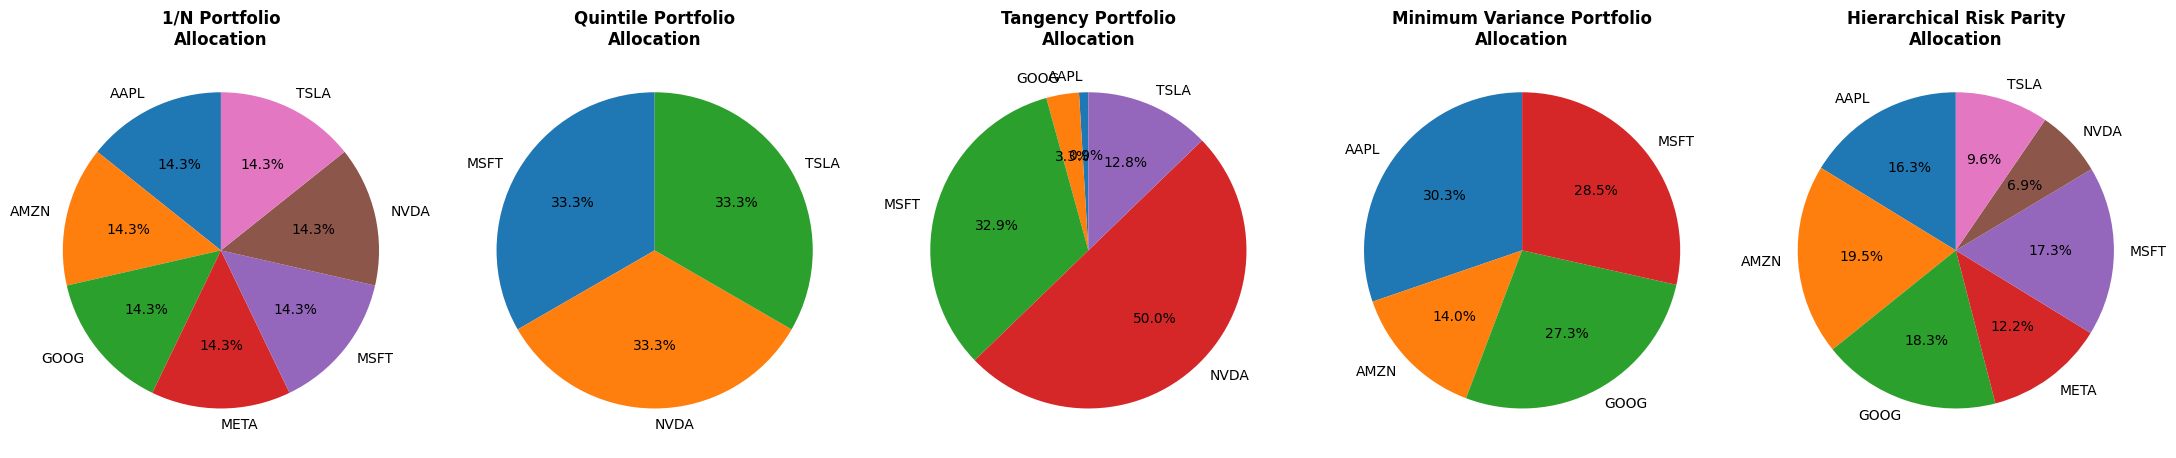

In [36]:
bt.show_pies(strats)

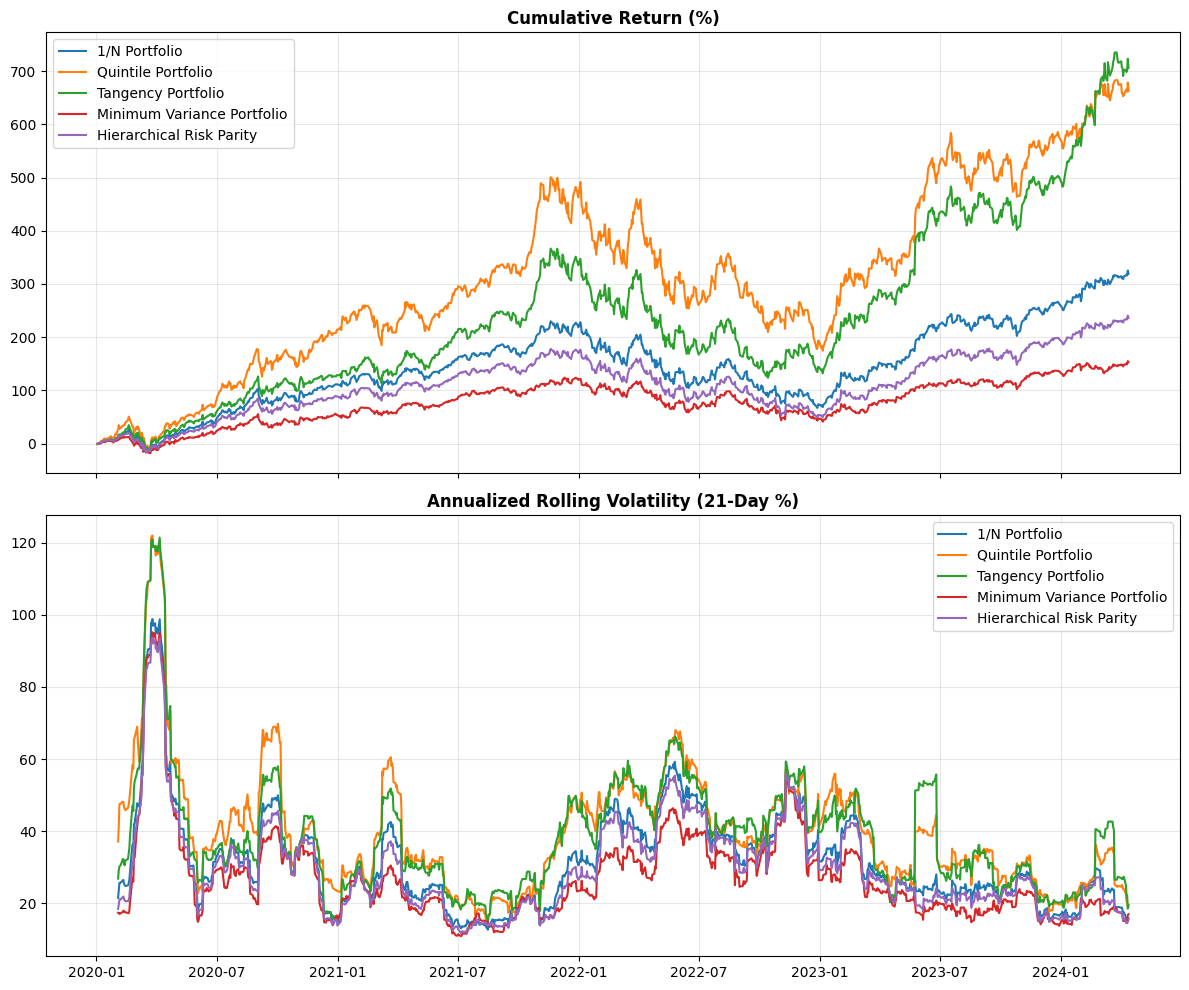

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
bt.show_performance_curves(strats, filename="Portfolio_Analysis.xlsx")

/tmp/ipykernel_3751/1156526797.py:172: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rolling, x="Sharpe Ratio", y="Method", palette=palette,


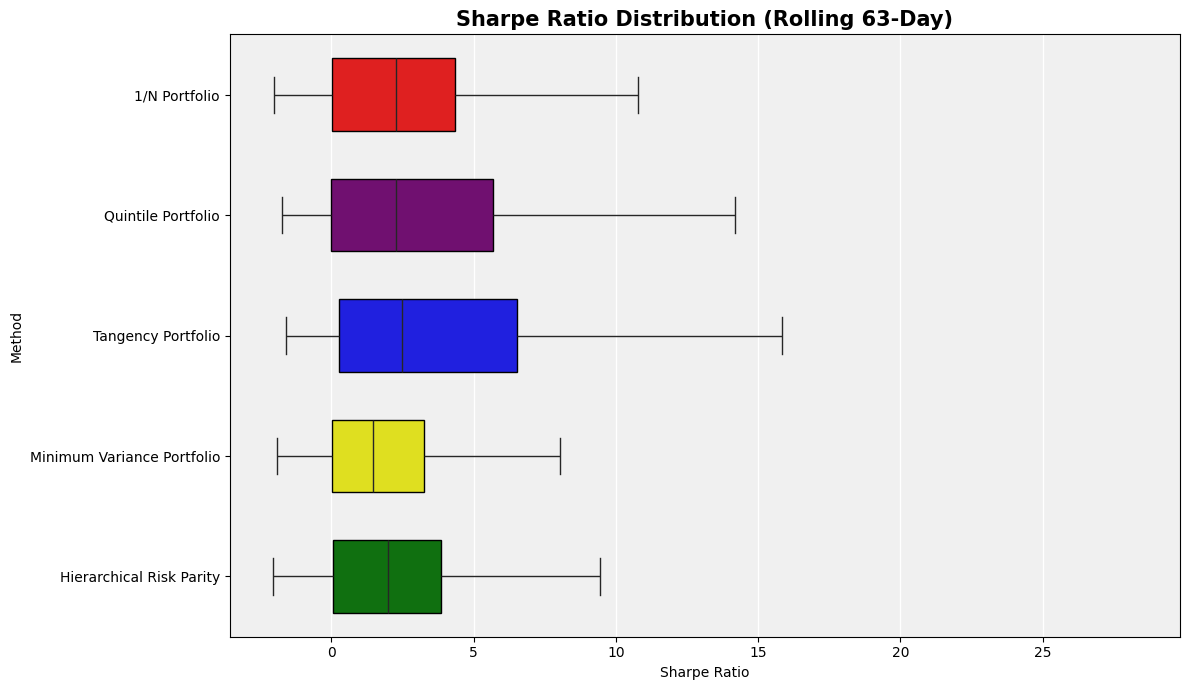

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
bt.show_sharpe_distribution(strats)